In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
(X_train,y_train),(X_test,y_test) = tf.keras.datasets.mnist.load_data()

print("training images: ",X_train.shape)
print("testingt data :",X_test.shape)

training images:  (60000, 28, 28)
testingt data : (10000, 28, 28)


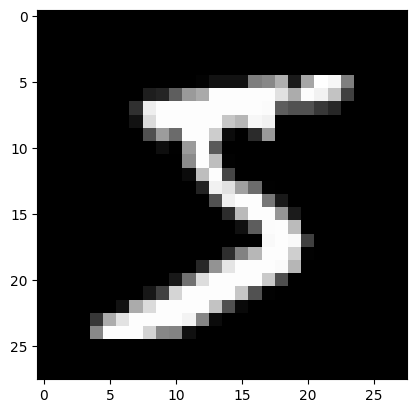

In [ ]:
plt.imshow(X_train[0],cmap="gray")


In [ ]:

print(X_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

print("max pixel :", X_train.max())

max pixel : 1.0


In [ ]:
X_train = X_train.reshape(60000,784)
print(X_train[0])
print(y_train[:10])


[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128,activation="relu",input_shape=(784,)),
    tf.keras.layers.Dense(64,activation="relu"),
    tf.keras.layers.Dense(10,activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(X_train,y_train,epochs=10,batch_size=30,validation_split=0.2)

Epoch 1/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9231 - loss: 0.2626 - val_accuracy: 0.9603 - val_loss: 0.1310
Epoch 2/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9665 - loss: 0.1106 - val_accuracy: 0.9651 - val_loss: 0.1176
Epoch 3/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9762 - loss: 0.0775 - val_accuracy: 0.9716 - val_loss: 0.0949
Epoch 4/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9815 - loss: 0.0579 - val_accuracy: 0.9660 - val_loss: 0.1167
Epoch 5/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9853 - loss: 0.0463 - val_accuracy: 0.9749 - val_loss: 0.0997
Epoch 6/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9873 - loss: 0.0387 - val_accuracy: 0.9737 - val_loss: 0.0925
Epoch 7/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9898 - loss: 0.0311 - val_accuracy: 0.9737 - val_loss: 0.0953
Epoch 8/10
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9911 - loss: 0.0258 - 

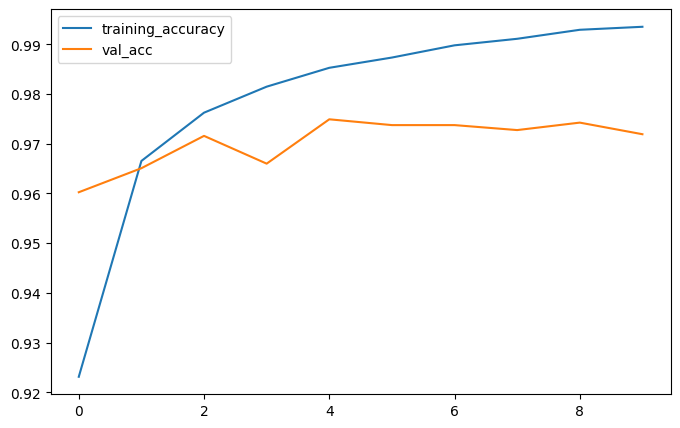

In [ ]:
plt.figure(figsize=(8, 5)) 
plt.plot(history.history["accuracy"], label="training_accuracy")  
plt.plot(history.history["val_accuracy"], label="val_acc")       
plt.legend()
plt.show()


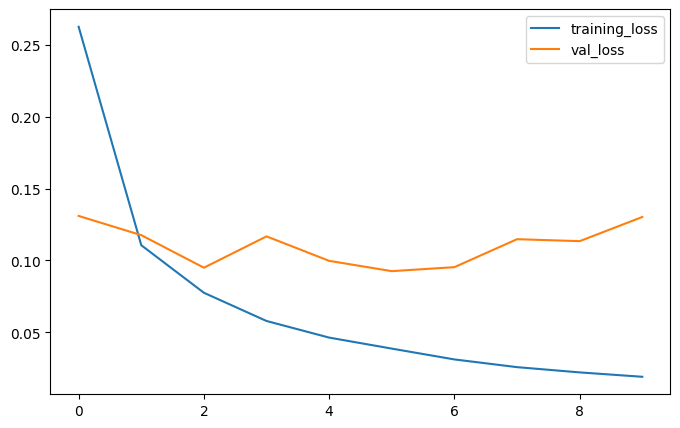

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="training_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

X_test = X_test.reshape(10000, 784)

model_pred = model.predict(X_test)

model_pred_classes = np.argmax(model_pred, axis=1)

print("Accuracy Score: ", accuracy_score(y_test, model_pred_classes))


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy Score:  0.9739


In [ ]:
print(model_pred[0])
print(model_pred_classes[0])

[0.         0.         0.         0.         0.         0.
 0.         0.99999994 0.         0.        ]
7


In [ ]:
y_pred = np.argmax(model_pred, axis=1)


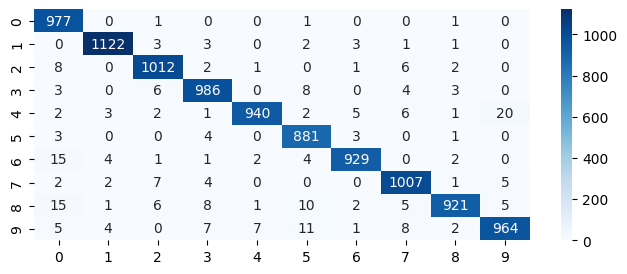

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,3))
sns.heatmap(cm,cmap='Blues',annot=True,fmt='d')
plt.show()

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.98      1032
           3       0.97      0.98      0.97      1010
           4       0.99      0.96      0.97       982
           5       0.96      0.99      0.97       892
           6       0.98      0.97      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.99      0.95      0.96       974
           9       0.97      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [ ]:
model.save("mnist.keras")
print("saved")


saved


In [ ]:
load_model = tf.keras.models.load_model("mnist.keras")
print("model loaded")

model loaded


In [ ]:
testing_predict = load_model.predict(X_test)
print(testing_predict)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[0.         0.         0.         ... 0.99999994 0.         0.        ]
 [0.         0.         0.99999994 ... 0.         0.         0.        ]
 [0.         0.99999994 0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
